In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
sys.path.append('../../')
import numpy as np
import torch
from model.MinAggGNN import MinAggGNN
import matplotlib.pyplot as plt

device = torch.device('cuda')
L = 2
m = 2
epochs = 20000
eta = 0.001

model = MinAggGNN(1, 8, L, 1, edge_dim = 1)
state_dict = torch.load('../model_progress/no_self_loops/model_final.pt')
model.load_state_dict(state_dict)
model.eval()
model.to(device)

c:\Users\heje197\AppData\Local\miniconda3\envs\minar\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MinAggGNN(1, 1, num_layers=2)

In [3]:
from MINAR.ComputationGraph import ComputationGraph, Circuit
from model.CustomLosses import MultiplicativeLoss
import torch_geometric as pyg
import networkx as nx

G = ComputationGraph(model)
G.add_inputs({'edge_attr' : [1, model.convs[0].agg_mlp.lins[0].weight[:,-1]],
              'input_self' : [3, model.convs[0].up_mlp.lins[0].weight[:,-1]]})
G.add_residual_connections({'edge_attr' : [5, model.convs[1].agg_mlp.lins[0].weight[:,-1].reshape(1,-1).cpu().detach()]})
G.add_residual_connections({4 : [7, model.convs[1].up_mlp.lins[0].weight[:,-8:].T.cpu().detach()]})
G.number_of_edges()

18240

In [4]:
# criterion = MultiplicativeLoss()
criterion = torch.nn.MSELoss()
test_data = torch.load('../data/test_data.pt', map_location=device, weights_only=False)
corrupted_data = torch.load('../data/test_data.pt', map_location=device, weights_only=False)
for data in test_data:
    data.edge_index, data.edge_attr = pyg.utils.remove_self_loops(data.edge_index, data.edge_attr)
for data_corr in corrupted_data:
    data_corr.edge_index, data_corr.edge_attr = pyg.utils.remove_self_loops(data_corr.edge_index, data_corr.edge_attr)
    data_corr.x = torch.zeros_like(data_corr.x, device=device)
    data_corr.edge_attr = torch.zeros_like(data_corr.edge_attr, device=device)

G.calculate_scores(test_data, corrupted_data, criterion, which = 'weight_grad')
G.calculate_scores(test_data, corrupted_data, criterion, which = 'EAP')
G.calculate_scores(test_data, corrupted_data, criterion, which = 'EAP-IG', steps=20)

In [5]:
# which = 'weight'
# which = 'weight_grad'
# which = 'EAP'
which = 'EAP-IG'
K = 8
C = Circuit(model, G, K=K, key=which, circuit_algorithm="longest_path")
print(C.number_of_edges())

18


In [6]:
test_loader = pyg.loader.DataLoader(test_data, batch_size = len(test_data))
criterion = MultiplicativeLoss()
mse_criterion = torch.nn.MSELoss()
num_reachable_test_nodes = sum([data.reachable.sum() for data in test_loader])
for data in test_loader:
    out = C.forward(data)
    mul_circuit_loss = float(criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    mse_circuit_loss = float(mse_criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    print(f'Circuit Test Loss: {mul_circuit_loss:.4f}')
    print(f'Circuit Test MSE Loss: {mse_circuit_loss:.4f}')

Circuit Test Loss: 0.0643
Circuit Test MSE Loss: 0.0000


In [7]:
test_loader = pyg.loader.DataLoader(test_data, batch_size = len(test_data))
criterion = MultiplicativeLoss()
num_reachable_test_nodes = sum([data.reachable.sum() for data in test_loader])
for data in test_loader:
    out = C.ablate_circuit(data)
    mul_circuit_loss = float(criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    mse_circuit_loss = float(mse_criterion(out[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    print(f'Ablated Circuit Test Loss: {mul_circuit_loss:.4f}')
    print(f'Ablated Circuit Test MSE Loss: {mse_circuit_loss:.4f}')

Ablated Circuit Test Loss: 25390.2617
Ablated Circuit Test MSE Loss: 0.0015


In [8]:
from IPython.display import display
from PIL import Image

from matplotlib import colors, cm
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
nx.relabel_nodes(C, {C.layers[-1][0] : 'output',
                     'input.0' : 'x_nbr',
                     'input_self' : 'x_self',
                     'edge_attr' : 'edge_weight'}, copy=False)
C.layers[0] = ['edge_weight', 'x_nbr', 'x_self']
C.layers[-1] = ['output']

C_pydot = nx.nx_agraph.to_agraph(C)
C_pydot.node_attr['shape'] = 'box'
C_pydot.node_attr['style'] = 'rounded, filled'

layer_colors = ['white', '#c6dbef', '#c6dbef', '#fdd0a2', '#fdd0a2', '#c6dbef', '#c6dbef', '#fdd0a2', 'white']
node_colors = {node : layer_colors[layer] for node, layer in nx.get_node_attributes(C, 'layer').items()}
for v in C_pydot.nodes():
    node = C_pydot.get_node(v)
    node.attr['fillcolor'] = node_colors[node]

edge_cmap=plt.cm.coolwarm
_, circuit_edge_weights = zip(*nx.get_edge_attributes(C,'weight').items())
abs_vmax = abs(max(circuit_edge_weights, key=abs))
normalized_weights = {edge : weight / (2*abs_vmax) + 0.5 for edge, weight in nx.get_edge_attributes(C,'weight').items()}
for u,v in C_pydot.edges():
    edge = C_pydot.get_edge(u,v)
    edge.attr['color'] = colors.to_hex(edge_cmap(normalized_weights[edge]))
    edge.attr["penwidth"] = 3.0

spine = ['x_nbr',
         'convs.0.agg_mlp.lins.0.58',
         'convs.0.agg_mlp.lins.1.63',
         'convs.0.up_mlp.lins.0.14',
         'convs.0.up_mlp.lins.1.2',
         'convs.1.agg_mlp.lins.0.16',
         'convs.1.agg_mlp.lins.1.55',
         'convs.1.up_mlp.lins.0.45',
         'output']
for i in range(len(spine)-1):
    edge = C_pydot.get_edge(spine[i],spine[i+1])
    edge.attr['weight'] = 100

spine2 = ['x_self',
          'convs.0.up_mlp.lins.0.39',
          'convs.0.up_mlp.lins.1.6',]
for i in range(len(spine2)-1):
    edge = C_pydot.get_edge(spine2[i],spine2[i+1])
    edge.attr['weight'] = 100

out_edge = C_pydot.get_edge('x_self','convs.0.up_mlp.lins.0.14')
# out_edge.weight = 50
out_edge.attr['tailport']='s'
out_edge.attr['headport']='nw'

a_layers = []
for l, layer in enumerate(C.layers):
    layer_a = C_pydot.add_subgraph(name=f'layer_{l}')
    layer_a.add_nodes_from(layer)
    layer_a.graph_attr['rank'] = l
    a_layers.append(layer_a)
a_layers[0].graph_attr['rank'] = 'source'


# C_pydot.graph_attr['rankdir']='LR'
C_pydot.graph_attr['nodesep'] = '.5'
C_pydot.graph_attr['splines'] = 'true'
C_pydot.graph_attr['dpi'] = 300
C_pydot.draw("../images/no_self_loops_circuit.pdf", prog="dot")
C_pydot.draw("../images/no_self_loops_circuit.png", prog="dot")
# display(Image.open("../images/no_self_loop_circuit.png"))

C:\Users\heje197\AppData\Local\Temp\ipykernel_7836\2002863833.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


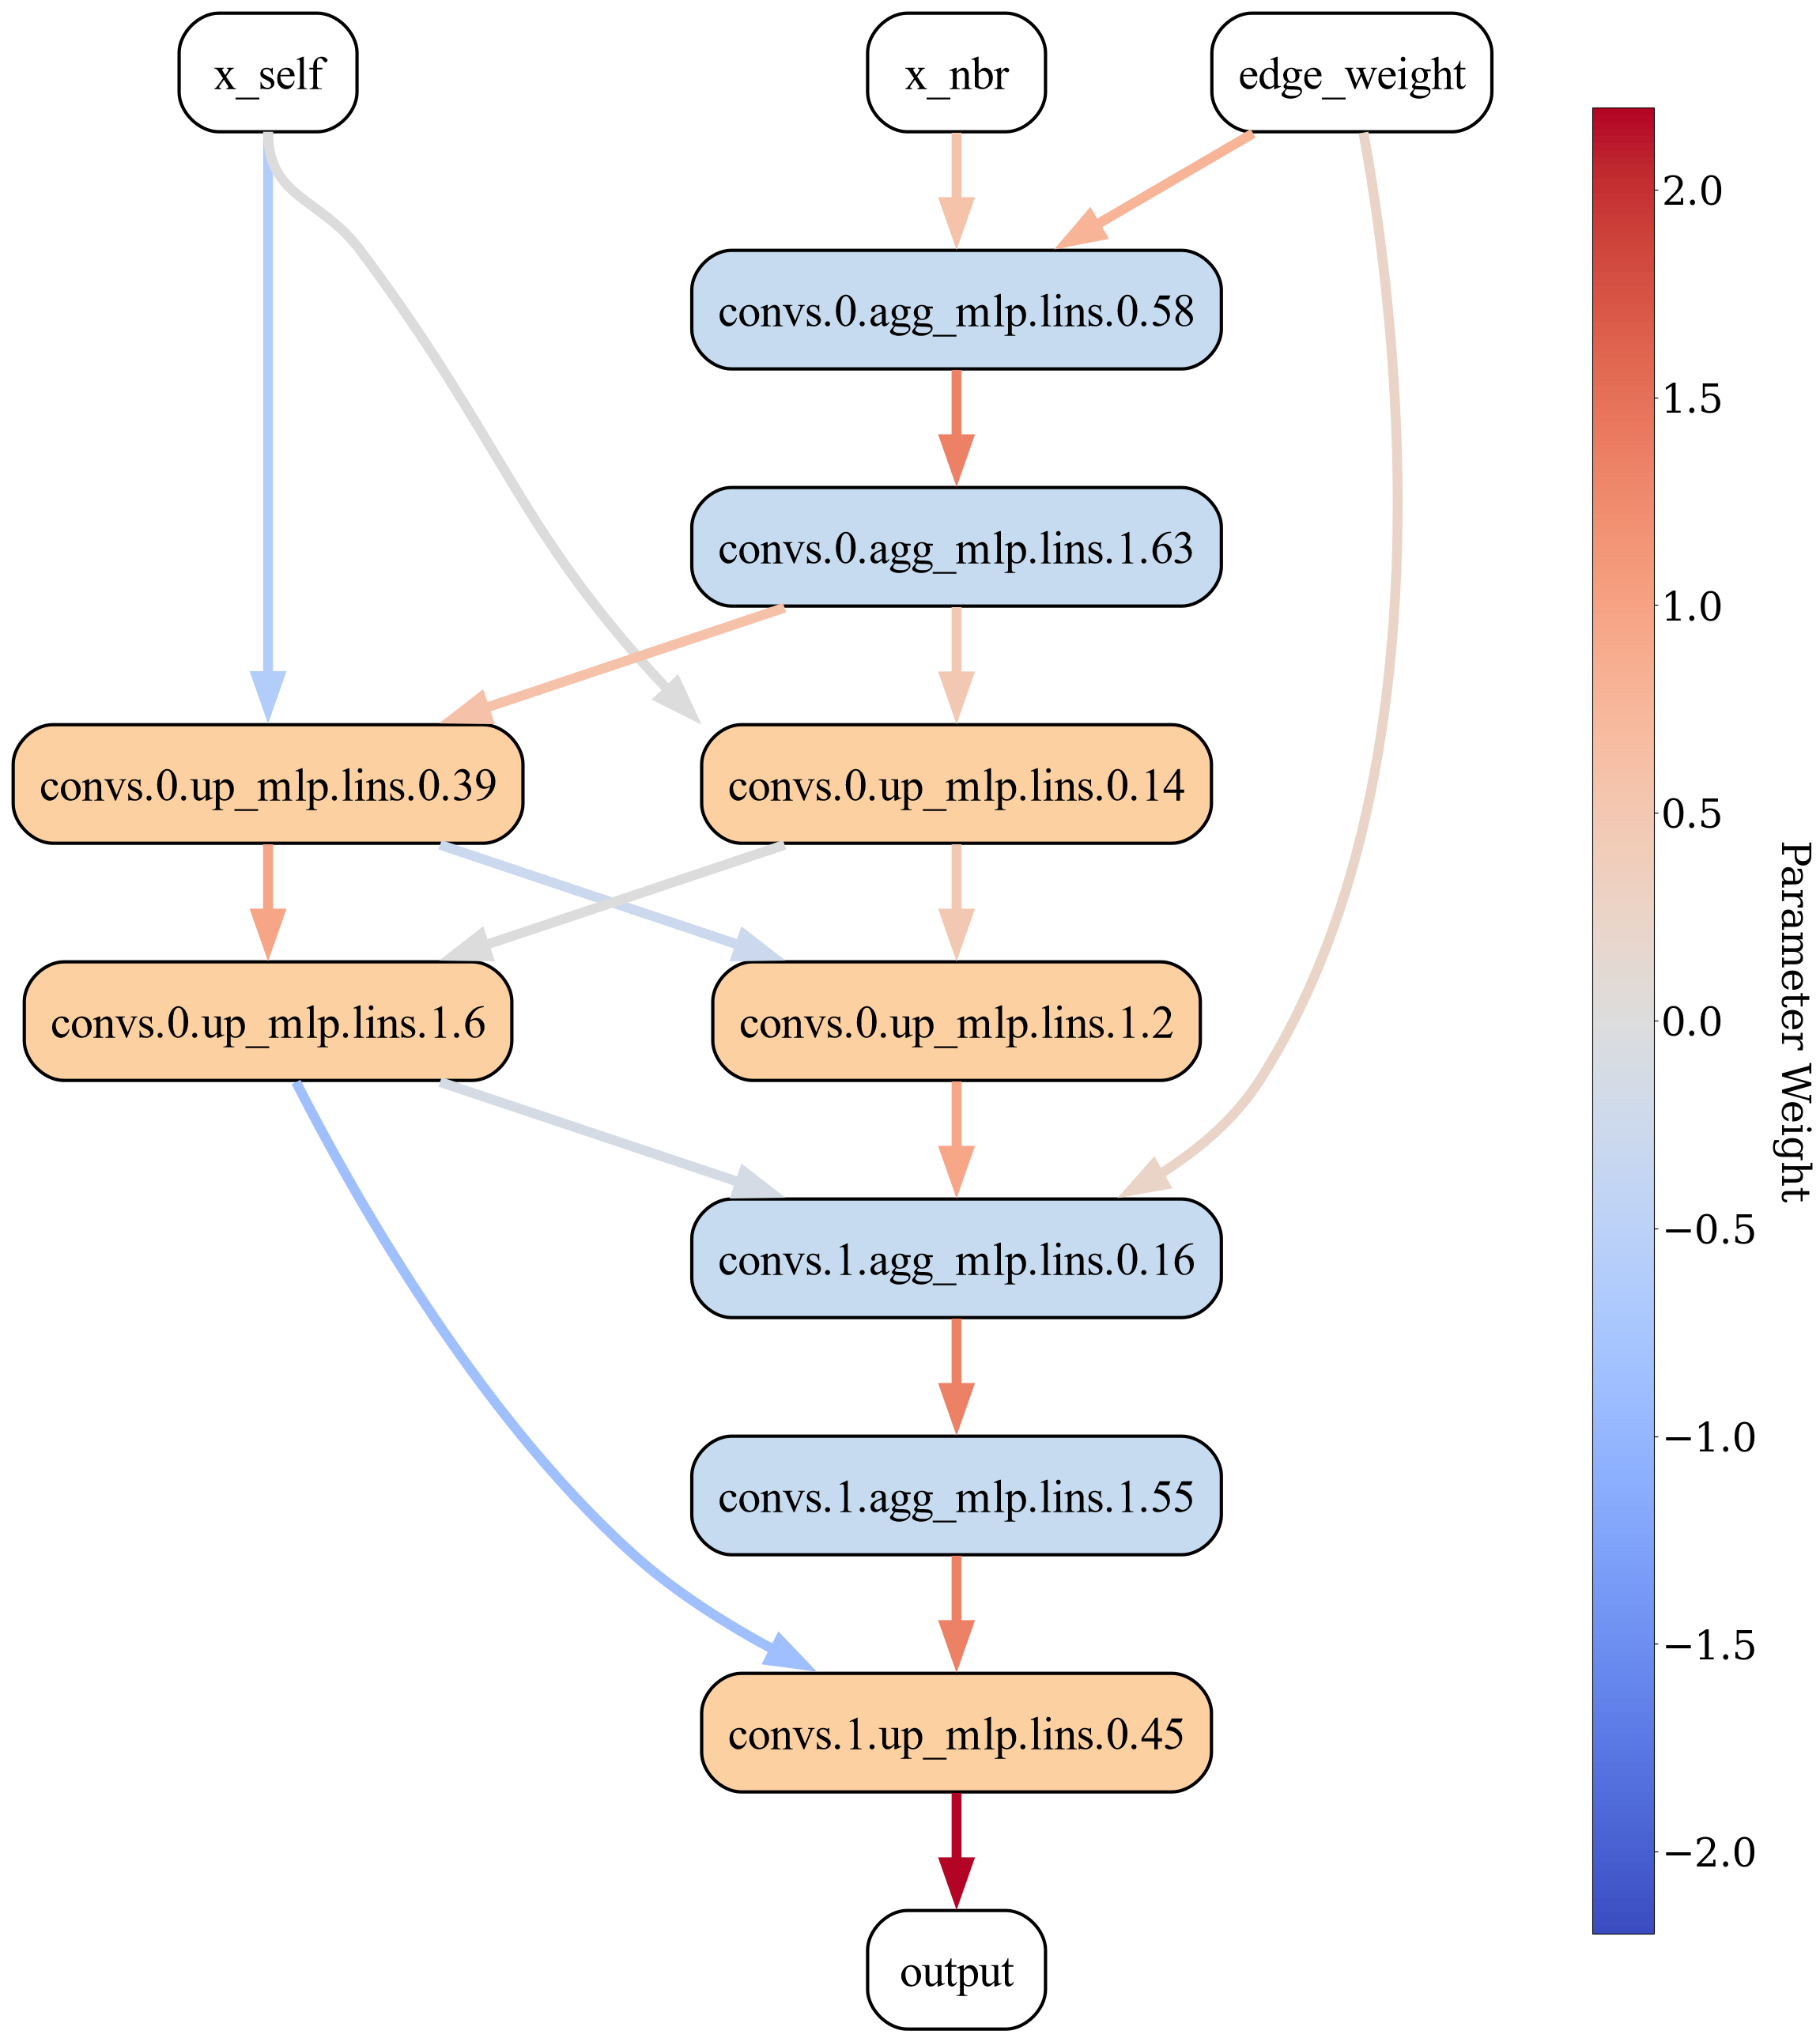

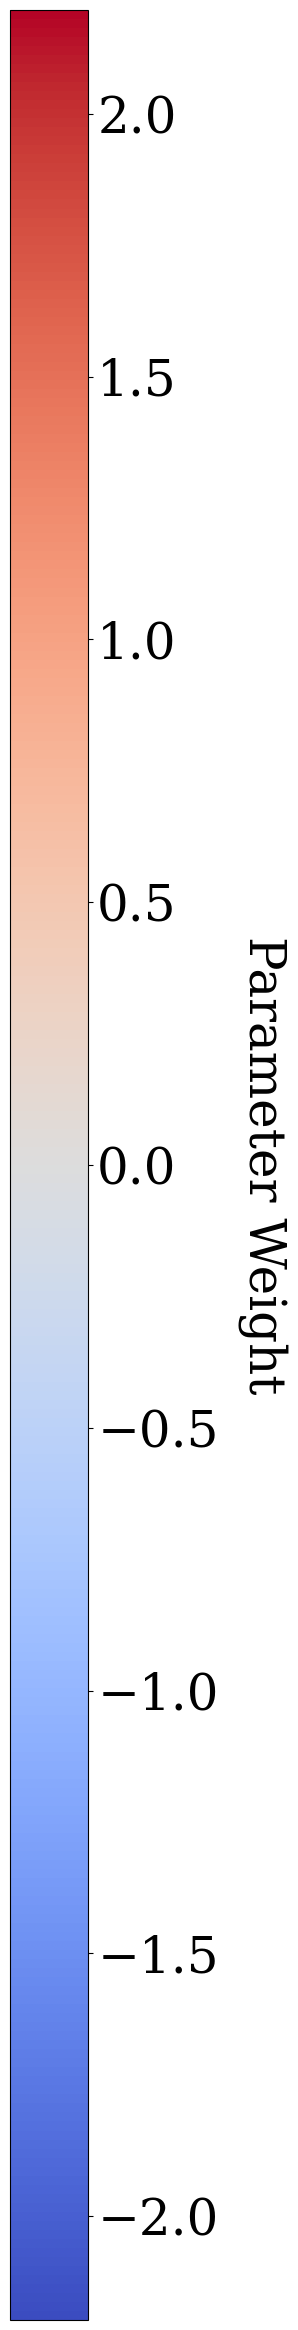

In [9]:
import matplotlib
# create and display a standalone colorbar for the circuit edge colors    
matplotlib.rcParams.update({'font.size':36})
max_edge_weight = max(circuit_edge_weights, key=abs)
vmin, vmax = -float(max_edge_weight), float(max_edge_weight)

norm = colors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap=edge_cmap, norm=norm)
sm.set_array([])

fig_cb, ax_cb = plt.subplots(figsize=(1, 30))
fig_cb.colorbar(sm, cax=ax_cb, orientation='vertical').set_label('Parameter Weight', rotation=270, labelpad=50)
plt.tight_layout()
plt.savefig("../images/no_self_loops_circuit_colorbar.pdf", bbox_inches='tight')
plt.savefig("../images/no_self_loops_circuit_colorbar.png", bbox_inches='tight')

circuit_image = Image.open("../images/no_self_loops_circuit.png")
colorbar_image = Image.open("../images/no_self_loops_circuit_colorbar.png")
colorbar_y = (circuit_image.height - colorbar_image.height) // 2
padding = 100
combined_w = circuit_image.width + padding + colorbar_image.width
combined_image = Image.new('RGBA', (combined_w, circuit_image.height), (255, 255, 255, 255))

combined_image.paste(circuit_image, (0, 0))
combined_image.paste(colorbar_image, (circuit_image.width + padding, colorbar_y))

combined_image = combined_image.convert('RGB')  # drop alpha for saving/display
combined_image.save("../images/no_self_loops_circuit_with_colorbar.png", dpi=(300,300))
display(combined_image)

In [10]:
C = Circuit(model, G, K=K, key=which, circuit_algorithm="longest_path")

checkpoints = torch.load('../model_progress/no_self_loops/model_checkpoints.pt')
try:
    circuit_losses = torch.load('../model_progress/no_self_loops/circuit_losses.pt')
    circuit_mse_losses = torch.load('../model_progress/no_self_loops/circuit_mse_losses.pt')
    circuit_l1_norms = torch.load('../model_progress/no_self_loops/circuit_l1_norms.pt')
    print('Loaded existing circuit progress data.')
except:
    circuit_losses = []
    circuit_mse_losses = []
    circuit_l1_norms = torch.zeros(len(checkpoints))
    for i, checkpoint in enumerate(checkpoints):
        model.load_state_dict(checkpoint)
        C.model_state_dict = checkpoint
        for data in test_loader:
            G_tmp = ComputationGraph(model)
            G_tmp.add_inputs({'edge_attr' : [1, model.convs[0].agg_mlp.lins[0].weight[:,-1]],
                'input_self' : [3, model.convs[0].up_mlp.lins[0].weight[:,-1]]})
            G_tmp.add_residual_connections({'edge_attr' : [5, model.convs[1].agg_mlp.lins[0].weight[:,-1].reshape(1,-1).cpu().detach()]})
            G_tmp.add_residual_connections({4 : [7, model.convs[1].up_mlp.lins[0].weight[:,-8:].T.cpu().detach()]})
            for e in C.edges:
                circuit_l1_norms[i] += float(G_tmp.edges[e]['weight'])
            circuit_out = C.forward(data).flatten()
            circuit_losses.append(float(criterion(circuit_out[data.reachable], data.y[data.reachable]).detach() / num_reachable_test_nodes))
            circuit_mse_losses.append(float(mse_criterion(circuit_out[data.reachable], data.y[data.reachable]).detach() / num_reachable_test_nodes))
    torch.save(circuit_losses, '../model_progress/no_self_loops/circuit_losses.pt')
    torch.save(circuit_mse_losses, '../model_progress/no_self_loops/circuit_mse_losses.pt')
    torch.save(circuit_l1_norms, '../model_progress/no_self_loops/circuit_l1_norms.pt')

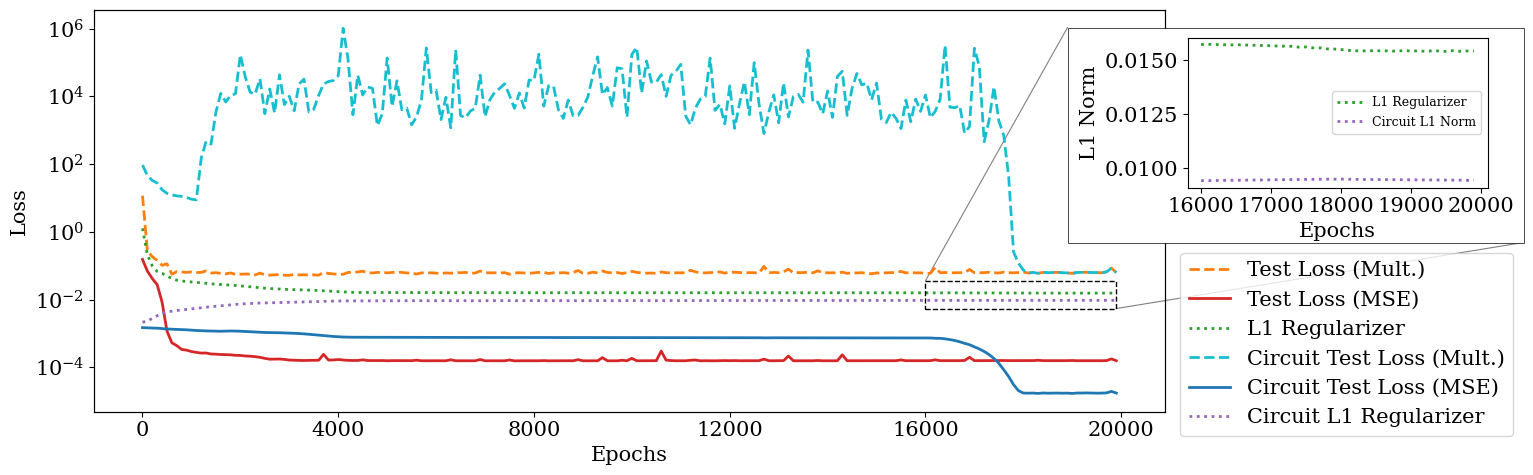

In [11]:
from matplotlib.patches import ConnectionPatch, Rectangle
test_losses = torch.load('../model_progress/no_self_loops/test_losses.pt')
mse_losses = torch.load('../model_progress/no_self_loops/mse_losses.pt')
l1_regs = torch.load('../model_progress/no_self_loops/l1_regs.pt')

# combined plot: main loss plot with inset showing L1 norms (from cells above/below)
plt.rcParams['font.size'] = 15
plt.rcParams['font.family'] = 'serif'
plt.rcParams['lines.linewidth'] = 2

# prepare numpy arrays for plotting (safe for gpu tensors)
test_losses_np = test_losses[0:epochs:100].detach().cpu().numpy()
mse_losses_np = mse_losses[0:epochs:100].detach().cpu().numpy()
l1_regs_np = (eta * l1_regs)[0:epochs:100].detach().cpu().numpy()

circuit_losses_np = np.array(circuit_losses)
circuit_mse_np = np.array(circuit_mse_losses)
circuit_l1_np = (eta * circuit_l1_norms).detach().cpu().numpy()

num_ticks = 5

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# primary curves (test losses)
ax.plot(test_losses_np, label='Test Loss (Mult.)', color='tab:orange', ls='dashed')
ax.plot(mse_losses_np, label='Test Loss (MSE)', color='tab:red', ls='solid')
ax.plot(l1_regs_np, label='L1 Regularizer', color='tab:green', ls='dotted')

# secondary axis (top x-axis) for circuit quantities (different x-scale)
ax2 = ax.twiny()
ax2.plot(circuit_losses_np, color='tab:cyan', label='Circuit Test Loss (Mult.)', ls='dashed')
ax2.plot(circuit_mse_np, color='tab:blue', label='Circuit Test Loss (MSE)', ls='solid')
ax2.plot(circuit_l1_np, color='tab:purple', label='Circuit L1 Regularizer', ls='dotted')

# ticks and labels
ax.set_xticks(range(0, len(circuit_losses_np) + 1, max(1, len(circuit_losses_np) // num_ticks)))
ax.set_xticklabels(range(0, epochs + 1, max(1, epochs // num_ticks)))
ax2.set_xticks([])

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_yscale('log')

# add legend (combined)
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles1 + handles2, labels1 + labels2, bbox_to_anchor=(1.28, .49), loc='upper right')

plt.tight_layout()

# inset: L1-norm comparison (as in cell 7) placed inside the main figure
inset_ax = fig.add_axes([1.0, 0.6, 0.25, 0.3])  # [left, bottom, width, height] in figure coords
# determine zoom window in the main L1 array (mirror inset slice logic)
start_idx = 160
n = l1_regs_np.shape[0] - start_idx
n = max(1, n)
x_min, x_max = start_idx, start_idx + (n - 1)
y_min, y_max = float(circuit_l1_np[start_idx:x_max + 1].min()-4e-3), float(l1_regs_np[start_idx:x_max + 1].max()+.02)

# dashed rectangle on the main axes to indicate zoom region
zoom_rect = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                      facecolor='none', edgecolor='black', linewidth=1.0, linestyle='--', zorder=2)
ax.add_patch(zoom_rect)

# draw a slightly larger white rectangle in figure coordinates so it also covers inset axis labels
pad = 0.02
bbox = inset_ax.get_position()
x0 = bbox.x0 - .1
y0 = bbox.y0 - .11
w = bbox.width + 0.13
h = bbox.height + .13
rect = Rectangle((x0, y0), w, h,
                 transform=fig.transFigure,
                 facecolor='white',
                 edgecolor='black',
                 linewidth=0.5,
                 zorder=0)
fig.patches.append(rect)
# connecting lines from rectangle corners to inset (rect) corners using figure-fraction coords
con1 = ConnectionPatch(xyA=(x_max, y_min), coordsA="data",
                       xyB=(x0 + w, y0), coordsB="figure fraction",
                       axesA=ax, axesB=fig,
                       color='gray', linewidth=0.8)
con2 = ConnectionPatch(xyA=(x_min, y_max), coordsA="data",
                       xyB=(x0, y0 + h), coordsB="figure fraction",
                       axesA=ax, axesB=fig,
                       color='gray', linewidth=0.8)
ax.add_artist(con1)
ax.add_artist(con2)

inset_ax.set_zorder(1)
inset_ax.patch.set_alpha(0.0)
# choose the same slices used previously to focus on later epochs
main_l1_slice = l1_regs_np[160:] if l1_regs_np.shape[0] > 160 else l1_regs_np
circuit_l1_slice = circuit_l1_np[160:] if circuit_l1_np.shape[0] > 160 else circuit_l1_np

inset_ax.plot(main_l1_slice, label='L1 Regularizer', color='tab:green', ls='dotted')
inset_ax.plot(circuit_l1_slice, label='Circuit L1 Norm', color='tab:purple', ls='dotted')

n_xt = 4
inset_ax.set_xticks(range(0, max(1, len(main_l1_slice))+1, max(1, len(main_l1_slice) // n_xt)))
start_epoch = 16000
step_epoch = 1000
inset_ax.set_xticklabels(range(start_epoch, start_epoch + step_epoch * (n_xt + 1), step_epoch)[:len(inset_ax.get_xticks())])
inset_ax.set_xlabel('Epochs')
inset_ax.set_ylabel('L1 Norm')
inset_ax.legend(fontsize=9)
inset_ax.grid(False)
plt.savefig('../images/no_self_loop_grokking.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
model_mid = MinAggGNN(1, 8, L, 1, edge_dim = 1)
state_dict_mid = torch.load('../model_progress/no_self_loops/model_checkpoints.pt')[100]
model_mid.load_state_dict(state_dict_mid)
model_mid.eval()
model_mid.to(device)

G_mid = ComputationGraph(model_mid)
G_mid.add_inputs({'edge_attr' : [1, model_mid.convs[0].agg_mlp.lins[0].weight[:,-1]],
              'input_self' : [3, model_mid.convs[0].up_mlp.lins[0].weight[:,-1]]})
G_mid.add_residual_connections({'edge_attr' : [5, model_mid.convs[1].agg_mlp.lins[0].weight[:,-1].reshape(1,-1).cpu().detach()]})
G_mid.add_residual_connections({4 : [7, model_mid.convs[1].up_mlp.lins[0].weight[:,-8:].T.cpu().detach()]})

G_mid.calculate_scores(test_data, corrupted_data, criterion, which = 'EAP-IG', steps=20)

In [13]:
C_mid = Circuit(model_mid, G_mid, K=10, key='EAP-IG', circuit_algorithm="longest_path")
print(f'{C_mid.number_of_edges()} Edges')
for data in test_loader:
    out_mid = C_mid.forward(data)
    mul_circuit_loss_mid = float(criterion(out_mid[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    mse_circuit_loss_mid = float(mse_criterion(out_mid[data.reachable].flatten(), data.y[data.reachable]).detach()) / num_reachable_test_nodes
    print(f'Midpoint Circuit Test Loss: {mul_circuit_loss_mid:.4f}')
    print(f'Midpoint Circuit Test MSE Loss: {mse_circuit_loss_mid:.4f}')

22 Edges
Midpoint Circuit Test Loss: 0.0678
Midpoint Circuit Test MSE Loss: 0.0000


C:\Users\heje197\AppData\Local\Temp\ipykernel_7836\1846885500.py:97: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


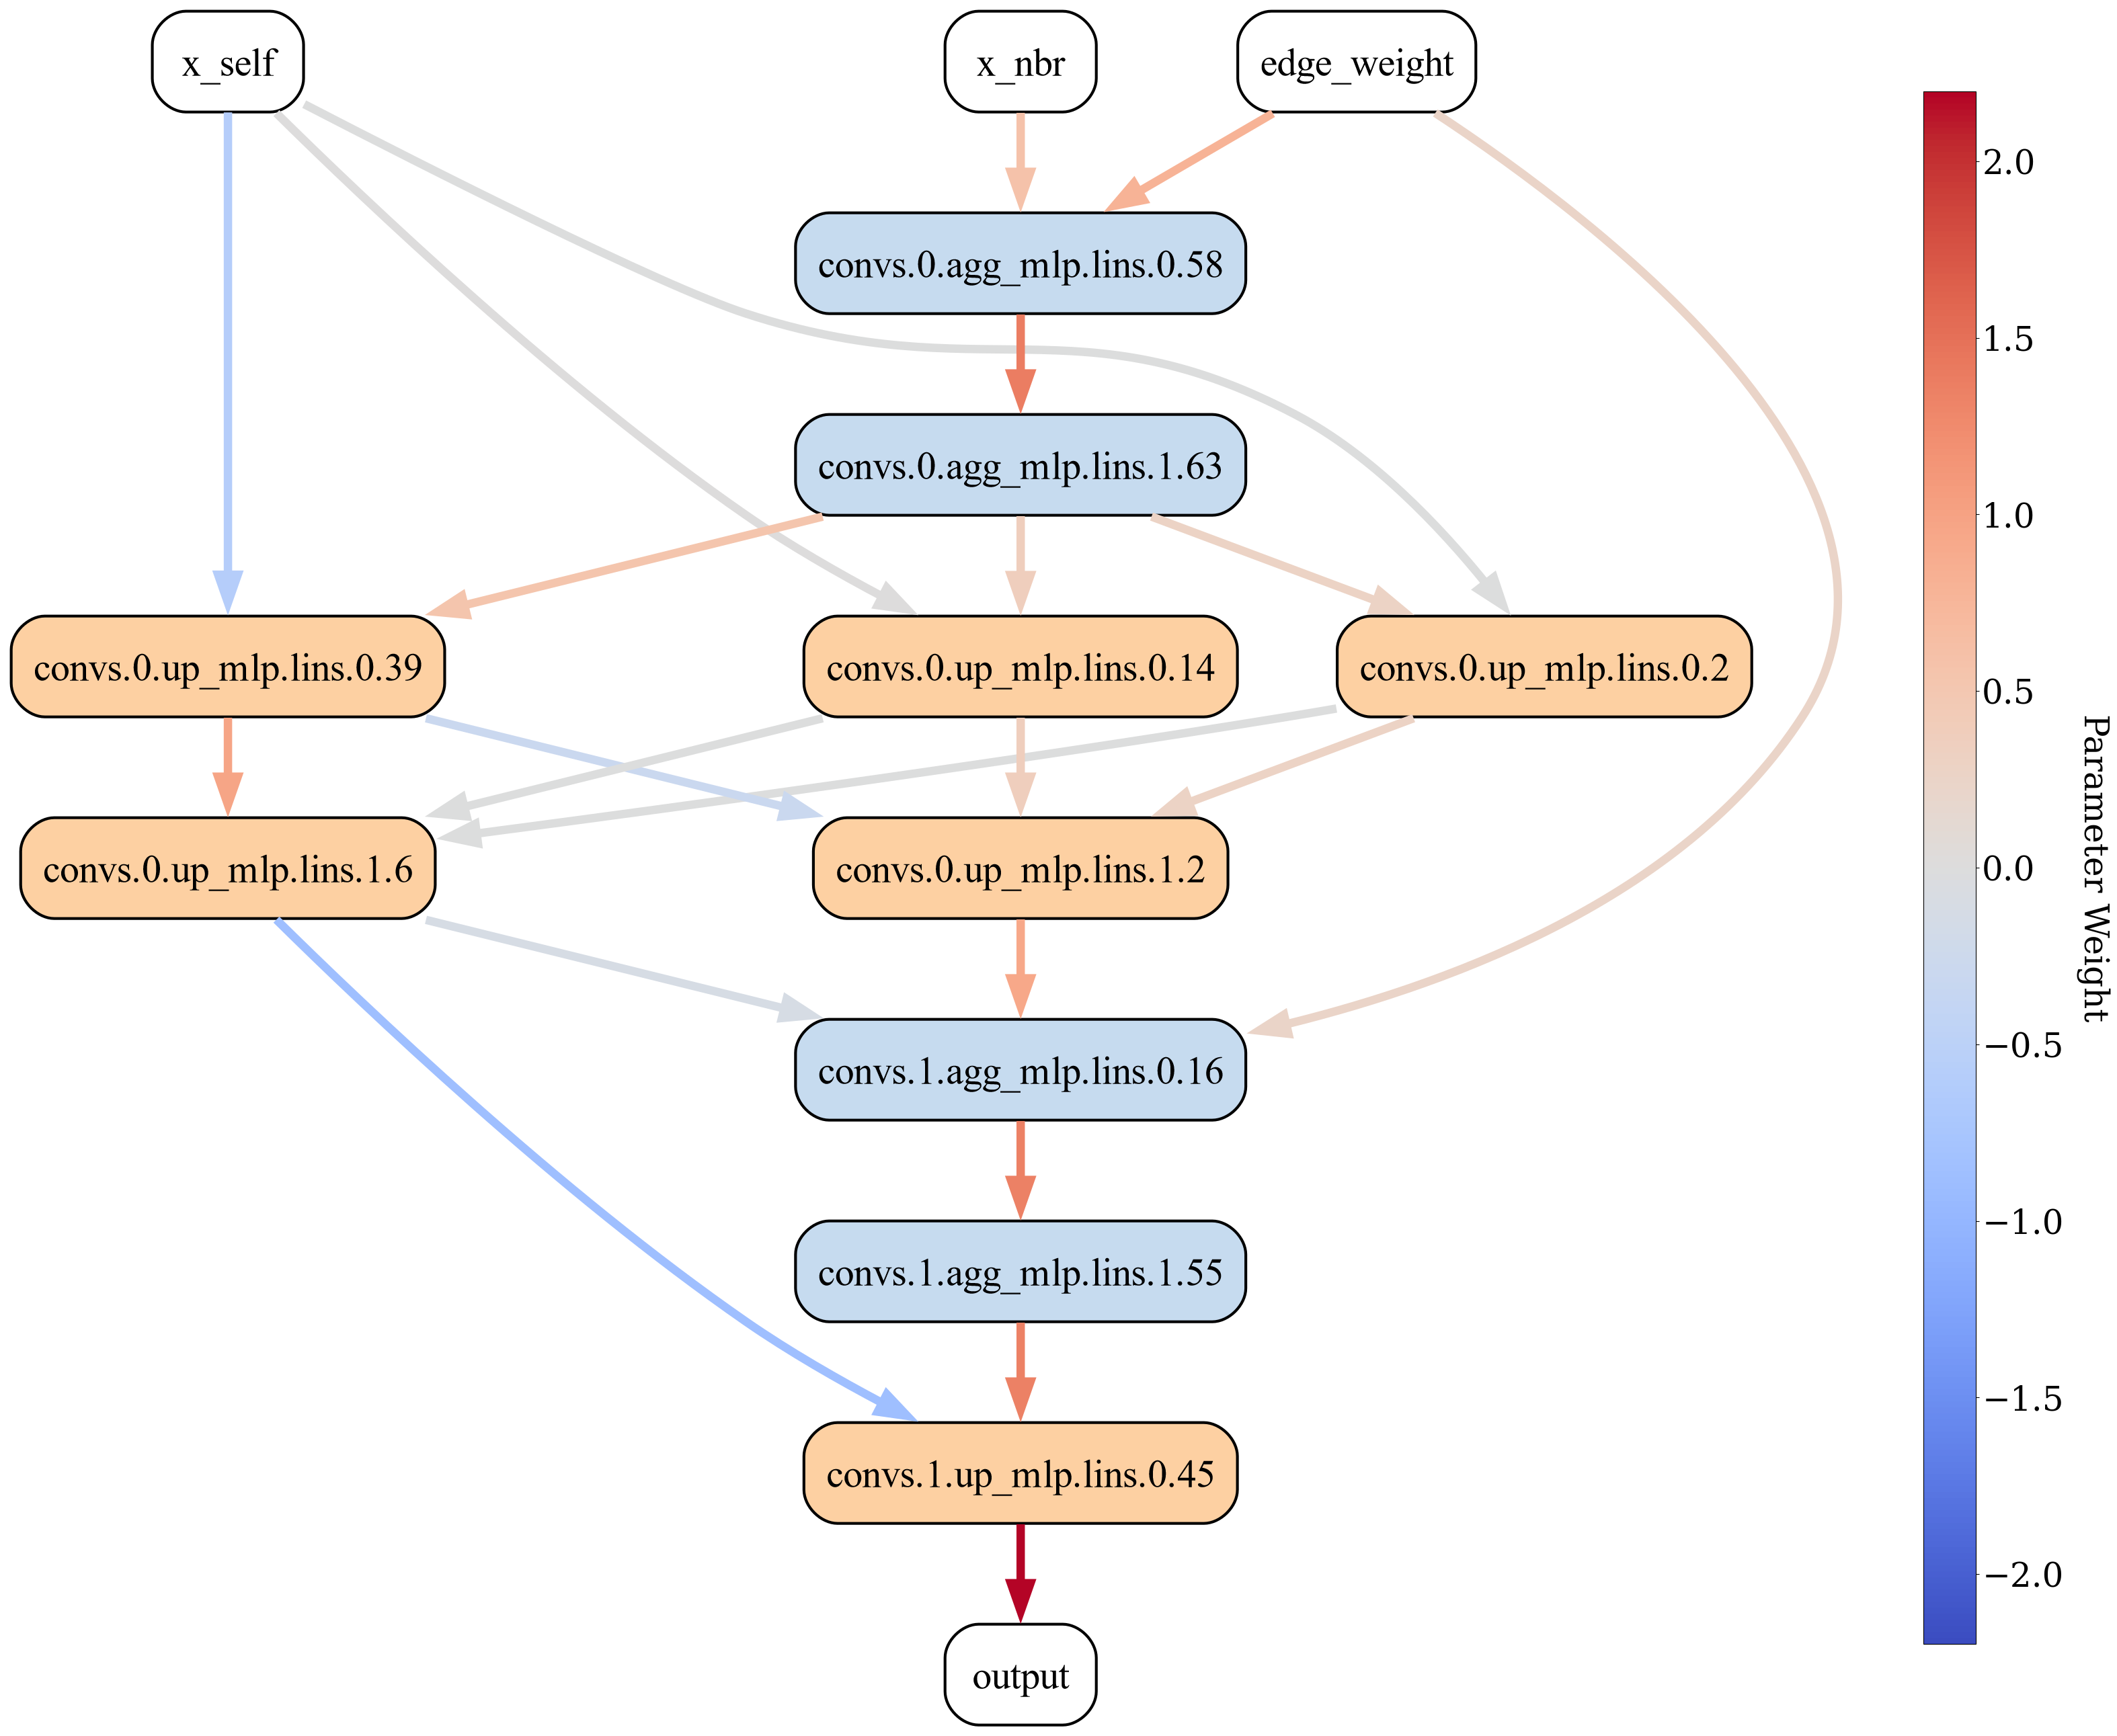

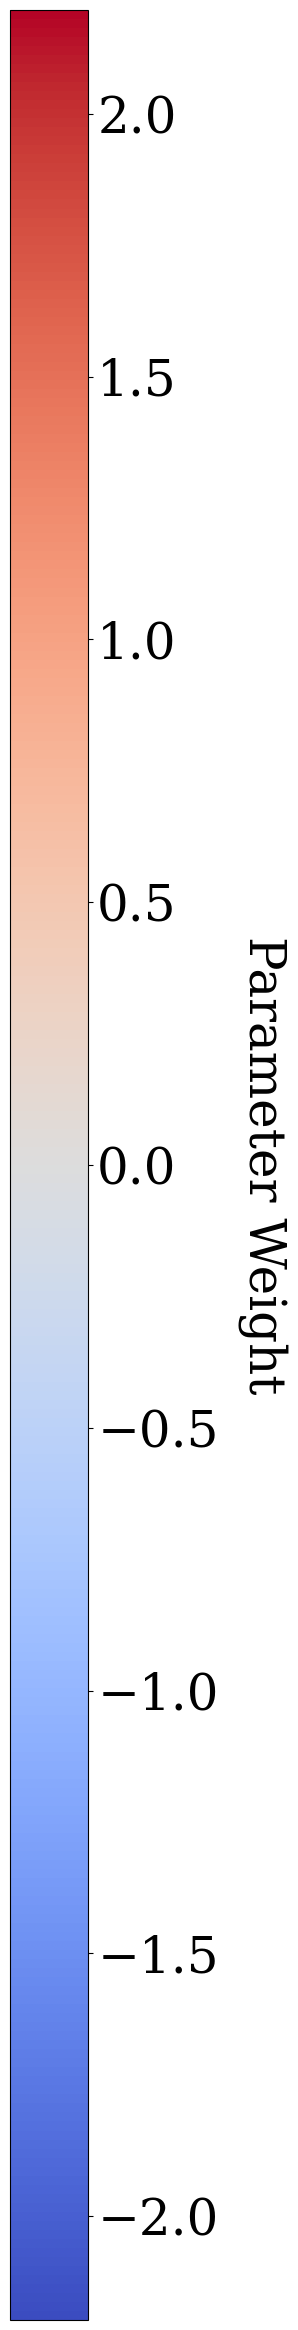

In [14]:
# visualize C_mid similarly to the prior C -> C_pydot cell
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 36

# relabel common input/output names (in-place)
nx.relabel_nodes(C_mid, {C_mid.layers[-1][0]: 'output',
                         'input.0': 'x_nbr',
                         'input_self': 'x_self',
                         'edge_attr': 'edge_weight'}, copy=False)

# ensure layer ordering matches display expectations
C_mid.layers[0] = ['edge_weight', 'x_nbr', 'x_self']
C_mid.layers[-1] = ['output']

# convert to pygraphviz AGraph
C_mid_pydot = nx.nx_agraph.to_agraph(C_mid)
C_mid_pydot.node_attr['shape'] = 'box'
C_mid_pydot.node_attr['style'] = 'rounded, filled'

# node fill colors by layer
layer_colors = ['white', '#c6dbef', '#c6dbef', '#fdd0a2', '#fdd0a2', '#c6dbef', '#c6dbef', '#fdd0a2', 'white']
node_colors_mid = {node: layer_colors[layer] for node, layer in nx.get_node_attributes(C_mid, 'layer').items()}
for v in C_mid_pydot.nodes():
    node = C_mid_pydot.get_node(v)
    node.attr['fillcolor'] = node_colors_mid.get(v, 'white')

# edge coloring by weight with same colormap as before
edge_cmap = edge_cmap  # reuse existing colormap
edge_weights_mid = nx.get_edge_attributes(C_mid, 'weight')
if len(edge_weights_mid) > 0:
    abs_vmax_mid = abs(max(edge_weights_mid.values(), key=lambda x: abs(x)))
    abs_vmax_mid = abs_vmax_mid if abs_vmax_mid != 0 else 1.0
else:
    abs_vmax_mid = 1.0

normalized_weights_mid = {(u, v): float(w) / (2 * abs_vmax_mid) + 0.5 for (u, v), w in edge_weights_mid.items()}

for u, v in C_mid_pydot.edges():
    edge_obj = C_mid_pydot.get_edge(u, v)
    w = normalized_weights_mid.get((u, v), None)
    if w is None:
        # try reversed key (directed vs undirected differences)
        w = normalized_weights_mid.get((v, u), 0.5)
    edge_obj.attr['color'] = colors.to_hex(edge_cmap(w))
    edge_obj.attr['penwidth'] = 3.0

# emphasize spine edges if present (only set when edge exists)
spine_nodes = ['x_nbr',
         'convs.0.agg_mlp.lins.0.58',
         'convs.0.agg_mlp.lins.1.63',
         'convs.0.up_mlp.lins.0.14',
         'convs.0.up_mlp.lins.1.2',
         'convs.1.agg_mlp.lins.0.16',
         'convs.1.agg_mlp.lins.1.55',
         'convs.1.up_mlp.lins.0.45',
         'output']
for i in range(len(spine_nodes) - 1):
    try:
        e = C_mid_pydot.get_edge(spine_nodes[i], spine_nodes[i + 1])
        if e:
            e.attr['weight'] = 200
    except Exception:
        pass

spine2_nodes = ['x_self',
                 'convs.0.up_mlp.lins.0.39',
                 'convs.0.up_mlp.lins.1.6']
for i in range(len(spine2_nodes) - 1):
    try:
        e = C_mid_pydot.get_edge(spine2_nodes[i], spine2_nodes[i + 1])
        if e:
            e.attr['weight'] = 20
    except Exception:
        pass

# create layer subgraphs for rank layout
a_mid_layers = []
for l, layer in enumerate(C_mid.layers):
    layer_a = C_mid_pydot.add_subgraph(name=f'mid_layer_{l}')
    layer_a.add_nodes_from(layer)
    layer_a.graph_attr['rank'] = l
    a_mid_layers.append(layer_a)
if a_mid_layers:
    a_mid_layers[0].graph_attr['rank'] = 'source'

C_mid_pydot.graph_attr['nodesep'] = '.5'
C_mid_pydot.graph_attr['splines'] = 'true'
C_mid_pydot.graph_attr['dpi'] = 300

# output files and display
C_mid_pydot.draw("../images/no_self_loops_circuit_mid.pdf", prog="dot")
C_mid_pydot.draw("../images/no_self_loops_circuit_mid.png", prog="dot")
# display(Image.open("../images/no_self_loops_circuit_mid.png"))

fig_cb, ax_cb = plt.subplots(figsize=(1, 30))
fig_cb.colorbar(sm, cax=ax_cb, orientation='vertical').set_label('Parameter Weight', rotation=270, labelpad=50)
plt.tight_layout()
plt.savefig("../images/no_self_loops_circuit_mid_colorbar.pdf", bbox_inches='tight')
plt.savefig("../images/no_self_loops_circuit_mid_colorbar.png", bbox_inches='tight')

circuit_image = Image.open("../images/no_self_loops_circuit_mid.png")
colorbar_image = Image.open("../images/no_self_loops_circuit_mid_colorbar.png")
colorbar_y = (circuit_image.height - colorbar_image.height) // 2
padding = 100
combined_w = circuit_image.width + padding + colorbar_image.width
combined_image = Image.new('RGBA', (combined_w, circuit_image.height), (255, 255, 255, 255))

combined_image.paste(circuit_image, (0, 0))
combined_image.paste(colorbar_image, (circuit_image.width + padding, colorbar_y))

combined_image = combined_image.convert('RGB')  # drop alpha for saving/display
combined_image.save("../images/no_self_loops_circuit_mid_with_colorbar.png", dpi=(300,300))
display(combined_image)

In [15]:
from tqdm import tqdm
mse_criterion = torch.nn.MSELoss()
score_methods = ['weight', 'weight_grad', 'EAP', 'EAP-IG']
circuit_mse_losses = {score : [] for score in score_methods}
circuit_test_losses = {score : [] for score in score_methods}
ablated_circuit_mse_losses = {score : [] for score in score_methods}
ablated_circuit_test_losses = {score : [] for score in score_methods}
actual_node_count = {score : [] for score in score_methods}
actual_edge_count = {score : [] for score in score_methods}
pbar = tqdm(range(20))
for K in pbar:
    for score in score_methods:
        for data in test_loader:
            C_tmp = Circuit(model, G, K=K, key=score)
            out = C_tmp.forward(data).flatten()
            out_ablate = C_tmp.ablate_circuit(data).flatten()
            mse_circuit_loss = float(mse_criterion(out[data.reachable], data.y[data.reachable]).detach()) / len(test_data)
            mul_circuit_loss = float(criterion(out[data.reachable], data.y[data.reachable]).detach()) / len(test_data)
            mse_circuit_loss_ablate = float(mse_criterion(out_ablate[data.reachable], data.y[data.reachable]).detach()) / len(test_data)
            mul_circuit_loss_ablate = float(criterion(out_ablate[data.reachable], data.y[data.reachable]).detach()) / len(test_data)
            circuit_mse_losses[score].append(mse_circuit_loss)
            circuit_test_losses[score].append(mul_circuit_loss)
            ablated_circuit_mse_losses[score].append(mse_circuit_loss_ablate)
            ablated_circuit_test_losses[score].append(mul_circuit_loss_ablate)
            actual_node_count[score].append(C_tmp.number_of_nodes())
            actual_edge_count[score].append(C_tmp.number_of_edges())

100%|██████████| 20/20 [02:10<00:00,  6.53s/it]


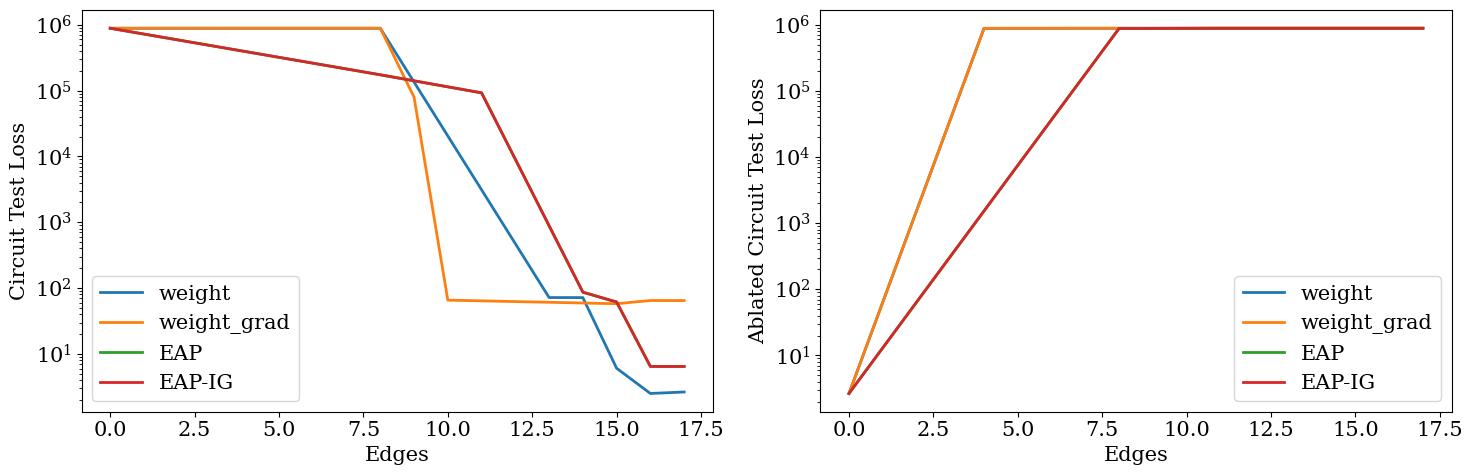

In [16]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 15
fig, ax = plt.subplots(1,2, figsize=(15,5))
for score in score_methods:
    ax[0].plot(actual_edge_count[score], circuit_test_losses[score], label=score)
    ax[1].plot(actual_edge_count[score], ablated_circuit_test_losses[score], label=score)

ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].legend()
ax[1].legend()
ax[0].set_xlabel('Edges')
ax[1].set_xlabel('Edges')
ax[0].set_ylabel('Circuit Test Loss')
ax[1].set_ylabel('Ablated Circuit Test Loss')
fig.tight_layout()